# M1.Ex4: Modeling Non-linear Patterns

### Name: Shaima Alqahtani

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M1/exercises/ex4_non-linear.ipynb)
- Raw Dataset: [bmi_and_life_expectancy.csv](https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/bmi_and_life_expectancy.csv)

In [25]:
import pandas as pd
import sklearn

### Step 1. Load the data


In [26]:
df = pd.read_csv("../../../datasets/bmi_and_life_expectancy.csv")
df.head()

,Country,Life expectancy,BMI
0,Afghanistan,52.8,20.62058
1,Albania,76.8,26.44657
2,Algeria,75.5,24.59620
3,Andorra,84.6,27.63048
4,Angola,56.7,22.25083


### Step 2.a Assign variables `X` to the features and `y` to the target

In [27]:
X = df[["BMI"]]      
y = df["Life expectancy"]

### Step 2.b print the type of each

In [28]:
print(type(X))
print(type(y))

<class 'pandas.DataFrame'>
<class 'pandas.Series'>


### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

In [29]:
print("Target type: numerical (continuous)")
print("Task type: regression")

Target type: numerical (continuous)
Task type: regression


### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [30]:
print("X shape:", X.shape)   
print("y shape:", y.shape)  

X shape: (163, 1)
y shape: (163,)


### Step 4. Summarize the distribution of the data (min, max, median, mean, and standard deviation)

In [31]:
df.describe()

,Life expectancy,BMI
count,163.000000,163.000000
mean,69.666933,24.792378
std,8.981933,2.427900
min,44.500000,19.866920
25%,63.450000,22.527940
50%,71.800000,25.320540
75%,76.500000,26.603960
max,84.600000,30.995630


### Step 5. Plot the feature vs the target

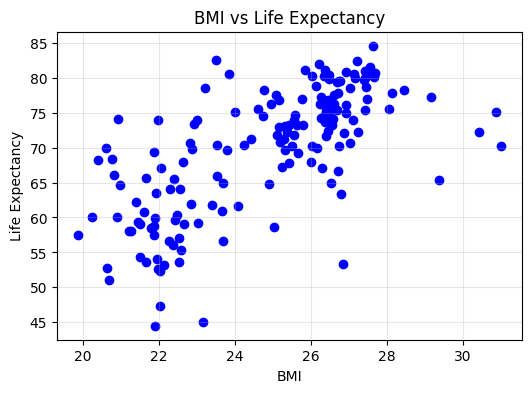

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.scatter(df["BMI"], df["Life expectancy"], color="blue")
plt.xlabel("BMI")
plt.ylabel("Life Expectancy")
plt.title("BMI vs Life Expectancy")
plt.grid(True, alpha=0.3)
plt.show()

### Step 6. What is the relationship between the feature and the target? (increasing or decreasing or none)

In [33]:
print("The relationship between BMI and life expectancy appears to be non-linear (not a simple straight line).")

The relationship between BMI and life expectancy appears to be non-linear (not a simple straight line).


### Step 7. Make two modeling techniques

First model is just a Linear Regression model: `from sklearn.linear_model import LinearRegression`

Second model: Use one of the previously mentioned methods to model a non-linear relationship

1. `from sklearn.tree import DecisionTreeRegressor`
2. or `from sklearn.preprocessing import PolynomialFeatures`

In [34]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

lin_model = LinearRegression()

poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X)
poly_model = LinearRegression()

### Step 8. Split the dataset into train and test sets

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_poly_train, X_poly_test, y_poly_train, y_poly_test = train_test_split(
    X_poly, y, test_size=0.2, random_state=42
)


### Step 9. Train both models on the training set

In [36]:
# Train linear model
lin_model.fit(X_train, y_train)

# Train polynomial model
poly_model.fit(X_poly_train, y_poly_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Step 10. Evaluate and compare which of the two models score better on the `train` set

In [37]:
from sklearn.metrics import r2_score

# Predictions on train
y_train_pred_lin = lin_model.predict(X_train)
y_train_pred_poly = poly_model.predict(X_poly_train)

r2_train_lin = r2_score(y_train, y_train_pred_lin)
r2_train_poly = r2_score(y_poly_train, y_train_pred_poly)

print("Train R^2 - Linear model:", r2_train_lin)
print("Train R^2 - Polynomial model:", r2_train_poly)

if r2_train_poly > r2_train_lin:
    print("On the TRAIN set, the polynomial (non-linear) model fits better.")
else:
    print("On the TRAIN set, the linear model fits better (or similar).")

Train R^2 - Linear model: 0.49395439141886677
Train R^2 - Polynomial model: 0.5758467003213981
On the TRAIN set, the polynomial (non-linear) model fits better.


### Step 11. Evaluate and compare which of the two models score better on the `test` set

In [38]:
# Predictions on test
y_test_pred_lin = lin_model.predict(X_test)
y_test_pred_poly = poly_model.predict(X_poly_test)

r2_test_lin = r2_score(y_test, y_test_pred_lin)
r2_test_poly = r2_score(y_poly_test, y_test_pred_poly)

print("Test R^2 - Linear model:", r2_test_lin)
print("Test R^2 - Polynomial model:", r2_test_poly)

if r2_test_poly > r2_test_lin:
    print("On the TEST set, the polynomial (non-linear) model performs better.")
else:
    print("On the TEST set, the linear model performs better (or similar).")

Test R^2 - Linear model: 0.3540313361524452
Test R^2 - Polynomial model: 0.358550548512783
On the TEST set, the polynomial (non-linear) model performs better.
